# Partie 1 : Classification binaire


In [2]:
import pandas as pd

data = pd.read_csv("sentiment_analysis 3.csv")
data.head()

,id,label,tweet
0,1,0,#fingerprint #Pregnancy Test https://goo.gl/h1...
1,2,0,Finally a transparant silicon case ^^ Thanks t...
2,3,0,We love this! Would you go? #talk #makememorie...
3,4,0,I'm wired I know I'm George I was made that wa...
4,5,1,What amazing service! Apple won't even talk to...


In [4]:
print(data.columns)
print("Taille :", data.shape)

Index(['id', 'label', 'tweet'], dtype='str')
Taille : (7920, 3)


In [6]:

data.isnull().sum()

id       0
label    0
tweet    0
dtype: int64

In [8]:
data.label.value_counts()

label
0    5894
1    2026
Name: count, dtype: int64

## Prétraitement du texte

In [10]:
# Supprimer les doublons
print("Avant :", len(data))
data = data.drop_duplicates()
print("Après :", len(data))

Avant : 7920
Après : 7920


In [12]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [13]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
stop_words.update(['coronavirus'])

In [14]:
def clean_text(text):
    # Minuscules
    text = text.lower()

    # Supprimer URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Supprimer caractères spéciaux et chiffres
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenisation
    tokens = word_tokenize(text)

    # Supprimer stopwords et lemmatiser
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    # Reconstituer le texte
    return ' '.join(tokens)

# Créer la nouvelle colonne
data['cleaned_text'] = data['tweet'].apply(clean_text)

In [17]:
# Comparaison avant / après nettoyage
data[["tweet", "cleaned_text"]].head()

,tweet,cleaned_text
0,#fingerprint #Pregnancy Test https://goo.gl/h1...,fingerprint pregnancy test android apps beauti...
1,Finally a transparant silicon case ^^ Thanks t...,finally transparant silicon case thanks uncle ...
2,We love this! Would you go? #talk #makememorie...,love would go talk makememories unplug relax i...
3,I'm wired I know I'm George I was made that wa...,im wired know im george made way iphone cute d...
4,What amazing service! Apple won't even talk to...,amazing service apple wont even talk question ...


## Vectorisation du texte (TF-IDF)

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Création du vectoriseur
tfidf = TfidfVectorizer()

# Vectorisation de la colonne cleaned_text
X_tfidf = tfidf.fit_transform(data["cleaned_text"])

print("Shape :", X_tfidf.shape)

Shape : (7920, 16444)


In [19]:
X_tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=tfidf.get_feature_names_out()
)

X_tfidf_df.head()

,aa,aaaahhhhhhh,aah,aalborg,aand,aapl,aarhus,aaron,aaronbrandt,aaronskip,...,zpictwittercomgskxbmkrto,zpictwittercomhnzltjvn,zpictwittercomnlmqvrxzv,zpictwittercomsschughesb,zsofimonster,zumies,zune,zunehd,zurich,zx
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


##  Séparation des données(Train et Test)

In [24]:
X = X_tfidf
y = data["label"]

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

Train : (6336, 16444)
Test  : (1584, 16444)


##  Entraînement des modèles et validation croisée (k = 5)


In [28]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

### Régression Logistique

In [30]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

# Validation croisée (k=5)
cv_scores_lr = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")

print("Scores des 5 folds :", cv_scores_lr)
print("Accuracy moyenne   :", cv_scores_lr.mean())
print("Écart-type         :", cv_scores_lr.std())

Scores des 5 folds : [0.85646688 0.85793212 0.8468824  0.87687451 0.85398579]
Accuracy moyenne   : 0.8584283398773526
Écart-type         : 0.009973962118141314


In [32]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy test :", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy test : 0.8686868686868687
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1179
           1       0.84      0.60      0.70       405

    accuracy                           0.87      1584
   macro avg       0.86      0.78      0.81      1584
weighted avg       0.87      0.87      0.86      1584



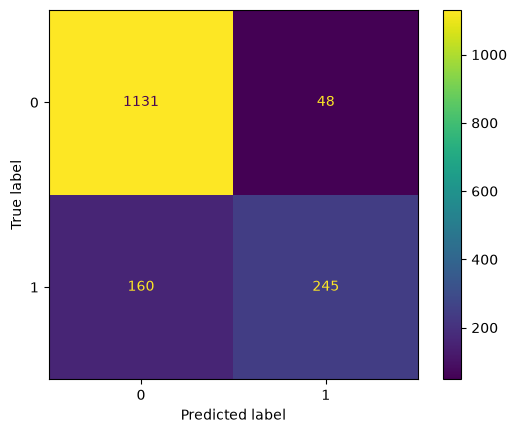

In [34]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

### SVM

In [36]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

# Validation croisée (k=5)
cv_scores_svm = cross_val_score(svm_model, X_train, y_train, cv=5, scoring="accuracy")

print("Scores des 5 folds :", cv_scores_svm)
print("Accuracy moyenne   :", cv_scores_svm.mean())
print("Écart-type         :", cv_scores_svm.std())

Scores des 5 folds : [0.87539432 0.88239937 0.87450671 0.88003157 0.86029992]
Accuracy moyenne   : 0.874526378165467
Écart-type         : 0.007686831814570427


In [38]:
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("Accuracy test :", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Accuracy test : 0.8882575757575758
              precision    recall  f1-score   support

           0       0.91      0.94      0.93      1179
           1       0.82      0.73      0.77       405

    accuracy                           0.89      1584
   macro avg       0.86      0.83      0.85      1584
weighted avg       0.89      0.89      0.89      1584



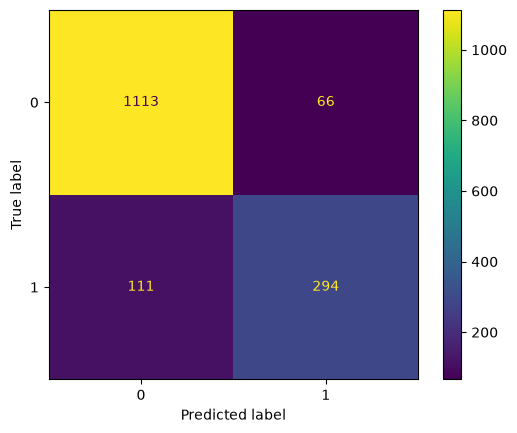

In [40]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm)
plt.show()

### Random Forest

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Validation croisée (k=5)
cv_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring="accuracy")

print("Scores des 5 folds :", cv_scores_rf)
print("Accuracy moyenne   :", cv_scores_rf.mean())
print("Écart-type         :", cv_scores_rf.std())

Scores des 5 folds : [0.85804416 0.86266772 0.851618   0.88555643 0.85793212]
Accuracy moyenne   : 0.8631636867933643
Écart-type         : 0.011735099570479683


In [43]:
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Accuracy test :", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy test : 0.86489898989899
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      1179
           1       0.81      0.61      0.70       405

    accuracy                           0.86      1584
   macro avg       0.84      0.78      0.81      1584
weighted avg       0.86      0.86      0.86      1584



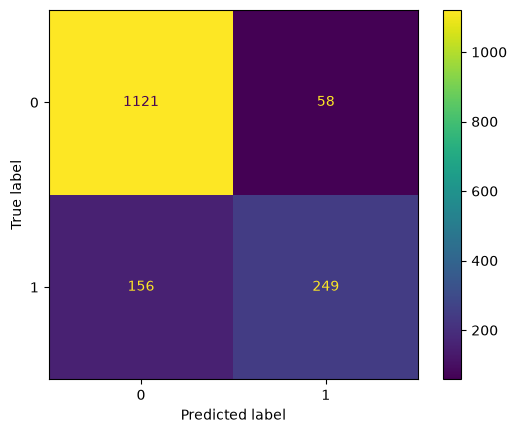

In [44]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.show()

## 6. Comparaison des modèles

In [48]:
resultats = pd.DataFrame({
    "Modèle": ["Régression Logistique", "SVM","Random Forest"],
    "Accuracy CV (moyenne)": [
        cv_scores_lr.mean(), cv_scores_svm.mean(),
        cv_scores_rf.mean()
    ],
    "Accuracy Test": [
        accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf)
    ]
})

resultats.round(3)

,Modèle,Accuracy CV (moyenne),Accuracy Test
0,Régression Logistique,0.858,0.869
1,SVM,0.875,0.888
2,Random Forest,0.863,0.865


In [50]:
# Test sur des nouvelles phrases 
texts = [
    "I really like this product",
    "This product is terrible",
    "The service was excellent",
    "I am very disappointed"
]

texts_clean = [clean_text(t) for t in texts]
texts_tfidf = tfidf.transform(texts_clean)

predictions = svm_model.predict(texts_tfidf)

for text, prediction in zip(texts, predictions):
    print(f"{text} --> {prediction}")

I really like this product --> 1
This product is terrible --> 1
The service was excellent --> 0
I am very disappointed --> 1
